In [17]:
from os.path import join 

import matplotlib.pyplot as plt 
import numpy as np 
import tidy3d as td 
from tidy3d import web 
from tidy3d.plugins.resonance import ResonanceFinder

from honeycomb_hex import create_hexagonal_honeycomb_slab

In [2]:
# ── Parameters (match the Lumerical script variables) ────────────────────────
a       = 1.0     # Lattice constant (um)
R       = 15      # Hexagonal radius in unit-cell repeats
radius  = 0.225   # Disk radius (um)  — corresponds to diameter 0.45 um
z_span  = 0.22    # Slab thickness (um)
n_si    = 3.47    # Refractive index of silicon
material = td.Medium(permittivity=n_si**2)

# Twist parameters for double-layer verification
ANGLE   = 0.75    # Twist angle (degrees)
GAP     = 0.3     # Gap between the two slabs (um)

# Randomized source/monitor setup
rng_seed = 20260311
num_sources = 12
num_time_monitors = 12
rand_span_xy = 1.0                 # random x/y range is [-1, 1] um
rand_span_z = GAP + 2 * z_span     # random z range is [-(GAP+2*z_span)/2, +(GAP+2*z_span)/2] um

In [3]:
cyls_bottom = create_hexagonal_honeycomb_slab(
    lattice_const=a, disk_radius=radius, slab_thickness=z_span,
    hex_radius=R, twist_angle=ANGLE, material=material, centerz=-z_span / 2 - GAP / 2,
)
cyls_top = create_hexagonal_honeycomb_slab(
    lattice_const=a, disk_radius=radius, slab_thickness=z_span,
    hex_radius=R, twist_angle=-ANGLE, material=material, centerz=z_span / 2 + GAP / 2,
)

# Build a single td.Structure from all cylinders
all_geom = td.GeometryGroup(geometries=cyls_bottom + cyls_top)
structure = td.Structure(geometry=all_geom, medium=material)

In [4]:
# sim size
lx = (R * a) * 2.0 + 4
ly = (R * a) * 2.0 + 1.5
lz = 4.5  # enlarged to include Gaussian beam waist plane at z = -2 um

Configured 2 GaussianBeam sources for circular polarization.
Beam waist center: (0, 0, -2.0), waist radius: 5.0 um


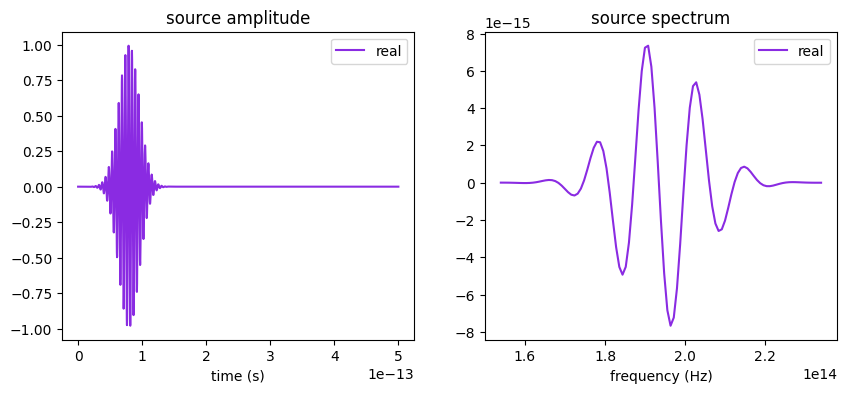

In [5]:
# Central frequency around which we'll look for the cavity mode (Hz)
wavelength = 1.55
freq0 = td.C_0 / wavelength

# Source bandwidth (Hz)
fwidth = 1e13

# Simulation run time (s)
run_time = 5e-12

# RNG remains for downstream randomized monitor placement (unchanged settings).
rng = np.random.default_rng(rng_seed)

# Circularly polarized normally incident Gaussian beam modeled by two orthogonal beams
# on the same source plane with pi/2 phase offset.
beam_center = (0, 0, -2.0)
beam_size = (lx, ly, 0)
beam_waist_radius = 5.0

gaussian_source_x = td.GaussianBeam(
    center=beam_center,
    size=beam_size,
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
    direction="+",
    pol_angle=0.0,
    angle_theta=0.0,
    angle_phi=0.0,
    waist_radius=beam_waist_radius,
    waist_distance=0.0,
    name="gaussian_x",
)

gaussian_source_y = td.GaussianBeam(
    center=beam_center,
    size=beam_size,
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth, phase=np.pi / 2),
    direction="+",
    pol_angle=np.pi / 2,
    angle_theta=0.0,
    angle_phi=0.0,
    waist_radius=beam_waist_radius,
    waist_distance=0.0,
    name="gaussian_y_pi2",
)

sources = [gaussian_source_x, gaussian_source_y]

print(f"Configured {len(sources)} GaussianBeam sources for circular polarization.")
print(f"Beam waist center: {beam_center}, waist radius: {beam_waist_radius} um")

# Plot pulse envelope and spectrum for reference from one source time profile.
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sources[0].source_time.plot(np.linspace(0, 5e-13, 2000), ax=ax[0])
sources[0].source_time.plot_spectrum(times=np.linspace(0, 5e-13, 2000), ax=ax[1])
plt.show()

In [6]:
# Starting time after the source has decayed for time series and
# for apodization of frequency domain monitors
t_start = 4e-13

# Multiple time series monitors near cavity center.
time_mnt_centers = [
    [
        rng.uniform(-rand_span_xy, rand_span_xy),
        rng.uniform(-rand_span_xy, rand_span_xy),
        rng.uniform(-0.5 * rand_span_z, 0.5 * rand_span_z),
    ]
    for _ in range(num_time_monitors)
]
time_series_mnts = [
    td.FieldTimeMonitor(
        center=center,
        size=[0, 0, 0],
        start=t_start,
        name=f"time_series_{i:02d}",
    )
    for i, center in enumerate(time_mnt_centers)
]

# Apodization to exclude the source pulse from the frequency-domain monitors
apodization = td.ApodizationSpec(start=t_start, width=2e-13)

# x-y near field monitor at z=0
freq1 = 210e12

field_mnt_xy = td.FieldMonitor(
    center=[0, 0, 0],
    size=[lx, ly, 0],
    freqs=[freq1],
    name="field_xy",
    apodization=apodization,
)

# Additional y-z monitor on plane x=0
field_mnt_x0 = td.FieldMonitor(
    center=[0, 0, 0],
    size=[0, ly, lz],
    freqs=[freq1],
    name="field_x0",
    apodization=apodization,
)

print(f"Configured {len(time_series_mnts)} point FieldTimeMonitor objects.")

Configured 12 point FieldTimeMonitor objects.


In [7]:
steps_per_unit_length = 20
grid_spec = td.GridSpec(
    grid_x=td.UniformGrid(dl=a / steps_per_unit_length),
    grid_y=td.UniformGrid(dl=a / steps_per_unit_length * np.sqrt(3) / 2),
    grid_z=td.AutoGrid(min_steps_per_wvl=steps_per_unit_length),
)

In [8]:
# Simulation
sim = td.Simulation(
    size=(lx, ly, lz),
    grid_spec=grid_spec,
    structures=[structure],
    sources=sources,
    monitors=time_series_mnts + [field_mnt_xy, field_mnt_x0],
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    # symmetry=(1, -1, 1),
    shutoff=1e-05,
)

print(f"Total number of grid points (millions): {sim.num_cells / 1e6:1.4f}")
print(f"Total number of time steps: {sim.num_time_steps}")
print(f"Number of sources: {len(sources)}")
print(f"Number of time monitors: {len(time_series_mnts)}")

Total number of grid points (millions): 59.2937
Total number of time steps: 83554
Number of sources: 2
Number of time monitors: 12


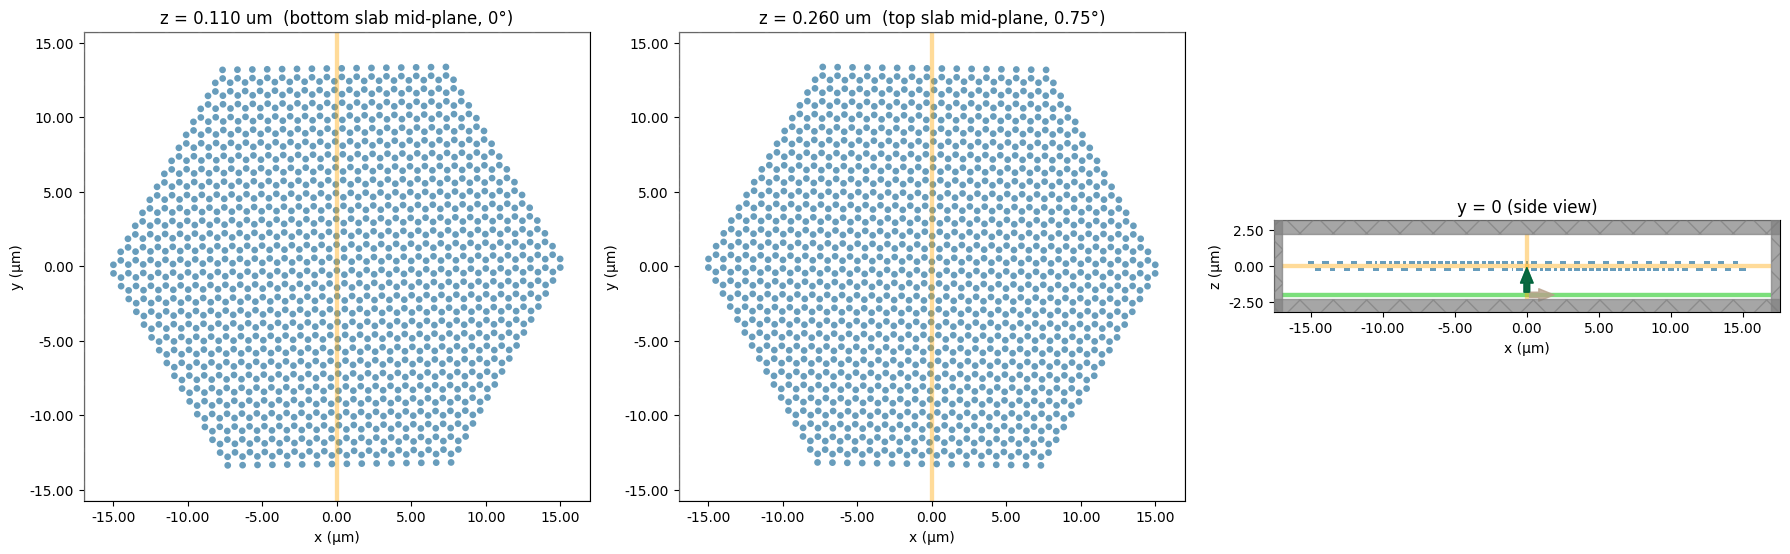

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# x-y at mid-plane of bottom slab
sim.plot(z=-z_span / 2 - GAP / 2, ax=axes[0])
axes[0].set_xlim(-lx / 2, lx / 2)
axes[0].set_ylim(-ly / 2, ly / 2)
axes[0].set_title(f"z = {z_span/2:.3f} um  (bottom slab mid-plane, 0°)")

# x-y at mid-plane of top slab
z_top_mid = z_span / 2 + GAP / 2
sim.plot(z=z_top_mid, ax=axes[1])
axes[1].set_xlim(-lx / 2, lx / 2)
axes[1].set_ylim(-ly / 2, ly / 2)
axes[1].set_title(f"z = {z_top_mid:.3f} um  (top slab mid-plane, {ANGLE}°)")

# x-z side view
sim.plot(y=0.5, ax=axes[2])
axes[2].set_title("y = 0 (side view)")

plt.tight_layout()
plt.show()

In [10]:
job = web.Job(simulation=sim, task_name="JieYao_v6", verbose=True)
estimated_cost = web.estimate_cost(job.task_id)
print(f'\n The estimated maximum cost is {estimated_cost:.3f} FlexCredits.')

01:36:17 Pacific Daylight Time Created task 'JieYao_v6' with resource_id        
                               'fdve-43dd2cb4-b460-491e-9363-237cd534eb93' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=914197;https://tidy3d.simulation.cloud/workbench?taskId=fdve-43dd2cb4-b460-491e-9363-237cd534eb93\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=53269;https://tidy3d.simulation.cloud/workbench?taskId=fdve-43dd2cb4-b460-491e-9363-237cd534eb93\taskId]8;;\
                               ]8;id=914197;https://tidy3d.simulation.cloud/workbench?taskId=fdve-43dd2cb4-b460-491e-9363-237cd534eb93\=]8;;\]8;id=529002;https://tidy3d.simulation.cloud/workbench?taskId=fdve-43dd2cb4-b460-491e-9363-237cd534eb93\fdve]8;;\]8;id=914197;https://tidy3d.simulation.cloud/workbench?taskId=fdve-43dd2cb4-b460-491e-9363-237cd534eb93\-43dd2cb4-b460-491e-9363-237cd534eb93']8;;\.

                               Task folder: ]8;id=309140;https://tidy3d.simulation.cloud/folders/folder-401c0a0c-8e13-4a51-9b19-e6b8ae1b963e\'default']8;;\.

d:\13700k-01 Project\twistedPCS\.venv\Lib\site-packages\rich\live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

01:36:24 Pacific Daylight Time Estimated FlexCredit cost: 1.501. Minimum cost   
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.


 The estimated maximum cost is 1.501 FlexCredits.


In [11]:
import datetime

# job = web.Job(simulation=sim, task_name="L3_opt", verbose=True)
sim_data = job.run(path="data/JieYao_v6.hdf5")

# Log task_id to file
task_id = job.task_id
timestamp = datetime.datetime.now().isoformat()
log_entry = f"{timestamp}\ttask_name=JieYao_v6\ttask_id={task_id}\n"
with open("data/task_log_JieYao.txt", "a") as f:
    f.write(log_entry)
print(log_entry.strip())

01:38:00 Pacific Daylight Time Estimated FlexCredit cost: 1.501. Minimum cost   
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

01:38:02 Pacific Daylight Time status = queued

                               To cancel the simulation, use                    
                               'web.abort(task_id)' or 'web.delete(task_id)' or 
                               abort/delete the task in the web UI. Terminating 
                               the Python script will not stop the job running  
                               on the cloud.

01:38:09 Pacific Daylight Time status = preprocess

01:38:14 Pacific Daylight Time starting up solver

...

01:39:57 Pacific Daylight Time status = success

01:39:59 Pacific Daylight Time View simulation result at                        
                               ]8;id=610262;https://tidy3d.simulation.cloud/workbench?taskId=fdve-43dd2cb4-b460-491e-9363-237cd534eb93\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=651136;https://tidy3d.simulation.cloud/workbench?taskId=fdve-43dd2cb4-b460-491e-9363-237cd534eb93\taskId]8;;\
                               ]8;id=610262;https://tidy3d.simulation.cloud/workbench?taskId=fdve-43dd2cb4-b460-491e-9363-237cd534eb93\=]8;;\]8;id=707936;https://tidy3d.simulation.cloud/workbench?taskId=fdve-43dd2cb4-b460-491e-9363-237cd534eb93\fdve]8;;\]8;id=610262;https://tidy3d.simulation.cloud/workbench?taskId=fdve-43dd2cb4-b460-491e-9363-237cd534eb93\-43dd2cb4-b460-491e-9363-237cd534eb93']8;;\.

01:40:15 Pacific Daylight Time Loading simulation from data\JieYao_v6.hdf5

01:40:16 Pacific Daylight Time WARNING: Simulation final field decay value of   
                               1.98e-05 is greater than the simulation shutoff  
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

2026-03-11T01:40:16.180922	task_name=JieYao_v6	task_id=fdve-43dd2cb4-b460-491e-9363-237cd534eb93


In [19]:
# sim_data = web.load(task_id="fdve-10d8a995-c992-477f-860a-dd7800004c9a", path="data/JieYao_v5.hdf5", verbose=True)

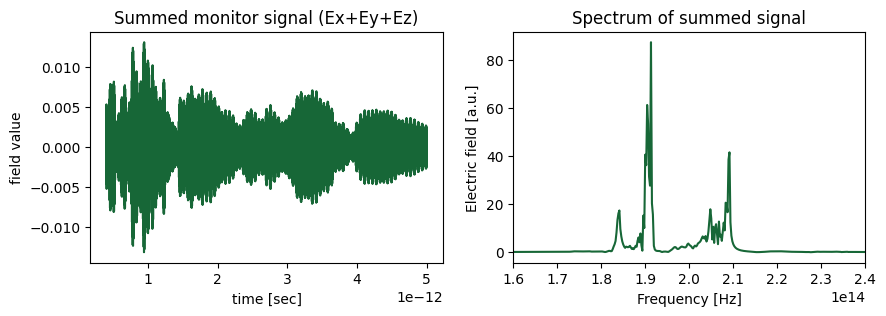

In [13]:
# Sum Ex + Ey + Ez across all randomized point monitors.
time_monitor_names = [mnt.name for mnt in time_series_mnts]

summed_signal = None
for name in time_monitor_names:
    tdata = sim_data[name]
    signal_xyz = tdata.Ex.squeeze() + tdata.Ey.squeeze() + tdata.Ez.squeeze()
    summed_signal = signal_xyz if summed_signal is None else (summed_signal + signal_xyz)

# Optional normalization by number of monitors.
time_series = summed_signal / len(time_monitor_names)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Plot time dependence
time_series.plot(ax=ax1)
ax1.set_title("Summed monitor signal (Ex+Ey+Ez)")

# Make frequency mesh and plot spectrum
dt = sim_data.simulation.dt
fmesh = np.linspace(-1 / dt / 2, 1 / dt / 2, time_series.size)
spectrum = np.fft.fftshift(np.fft.fft(time_series))

ax2.plot(fmesh, np.abs(spectrum))
ax2.set_xlim(1.6e14, 2.4e14)
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Electric field [a.u.]")
ax2.set_title("Spectrum of summed signal")
plt.show()

In [14]:
resonance_finder = ResonanceFinder(freq_window=(1.8e14, 2.4e14), init_num_freqs=100)
# ResonanceFinder takes monitor data directly; use one representative monitor for fitting.
resonance_data = resonance_finder.run(sim_data[time_monitor_names[0]])
resonance_data.to_dataframe()

,decay,Q,amplitude,phase,error
freq,,,,,
1.836403e+14,1.642434e+12,351.260891,7.185330e-04,0.500206,0.000744
1.841101e+14,1.036263e+12,558.158354,7.194966e-04,-3.116404,0.000481
1.848329e+14,1.690481e+12,343.493712,3.154048e-04,-2.355028,0.001332
1.855173e+14,1.543914e+12,377.495158,2.613011e-04,2.884936,0.000289
1.866623e+14,9.054037e+11,647.685611,9.826971e-05,1.025119,0.001110
1.874820e+14,1.704087e+12,345.634916,5.781821e-04,-2.325716,0.000923
1.881031e+14,3.753520e+11,1574.370691,1.503826e-04,-1.160264,0.000242
1.885376e+14,1.396519e+12,424.131720,2.489594e-03,1.991269,0.000166
1.889620e+14,9.513324e+11,624.010809,4.041780e-03,1.565004,0.000098


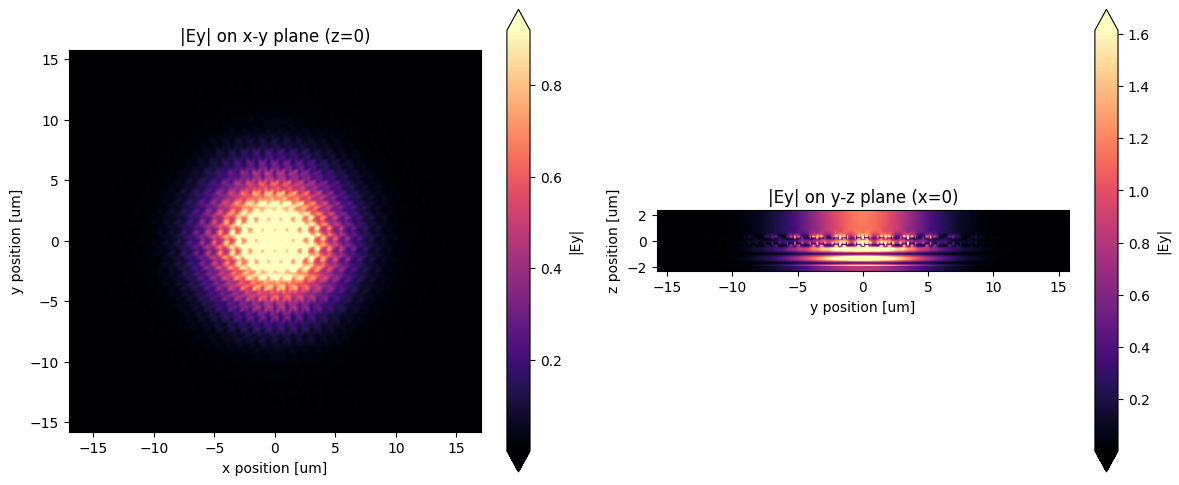

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sim_data.plot_field("field_xy", "Ey", val="abs", z=0, ax=axes[0], eps_alpha=0)
axes[0].set_title("|Ey| on x-y plane (z=0)")

sim_data.plot_field("field_x0", "Ey", val="abs", x=0, ax=axes[1], eps_alpha=0)
axes[1].set_title("|Ey| on y-z plane (x=0)")

plt.tight_layout()
plt.show()

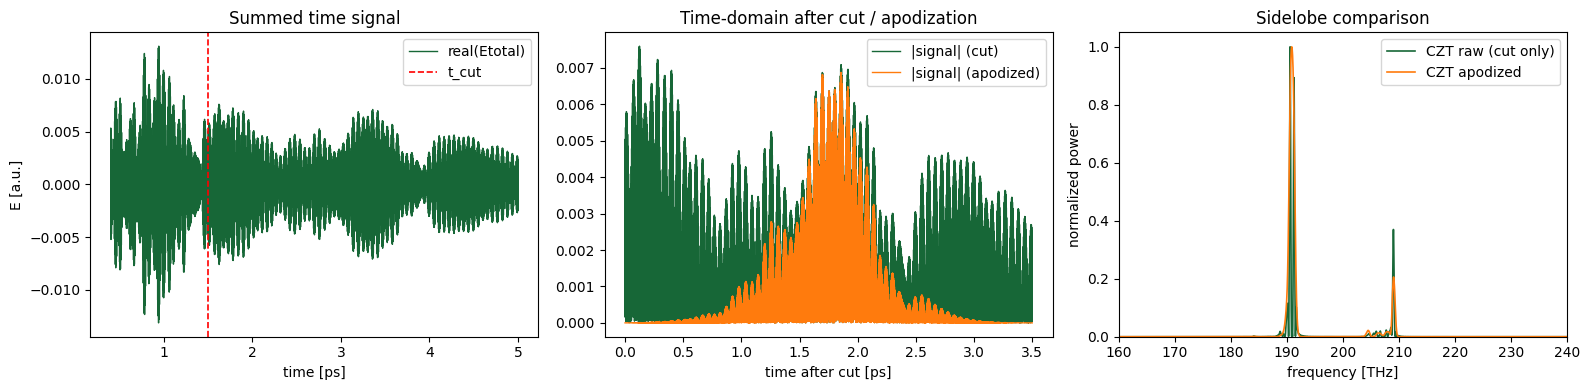

Applied t_cut = 1.50e-12 s, apod_width = 0.125, apod_center = 0.5
Use the apodized curve to assess sidelobe suppression around the main resonances.


In [16]:
# Lumerical-style sidelobe suppression analysis:
# 1) sum Ex+Ey+Ez over monitors,
# 2) remove initial transient (first 1.5e-12 s),
# 3) apply Gaussian apodization,
# 4) compute spectrum in a target band via CZT.

from scipy.signal import czt

# ---- user-tunable parameters ----
t_cut = 1.5e-12
apod_width = 0.125
apod_center = 0.5
f1, f2 = 1.6e14, 2.4e14
n_freq = 5000

# ---- aggregate monitor fields: Etotal = sum_j (Ex_j + Ey_j + Ez_j) ----
if "time_monitor_names" not in globals():
    time_monitor_names = [mnt.name for mnt in time_series_mnts]

Etotal = None
for name in time_monitor_names:
    mdat = sim_data[name]
    sig = mdat.Ex.squeeze() + mdat.Ey.squeeze() + mdat.Ez.squeeze()
    Etotal = sig if Etotal is None else (Etotal + sig)

# optional average over monitors for scale consistency
Etotal = Etotal / len(time_monitor_names)

# time axis from monitor data
if "t" in Etotal.coords:
    t = np.asarray(Etotal.coords["t"].values, dtype=float)
else:
    t = np.arange(Etotal.size) * float(sim_data.simulation.dt)

signal = np.asarray(Etotal.values, dtype=complex)

# ---- remove initial transient ----
mask = t >= t_cut
if mask.sum() < 10:
    raise RuntimeError("Too few samples remain after t_cut. Reduce t_cut or increase run_time.")

t_sel = t[mask]
sig_sel = signal[mask]

# shift time origin for cleaner phase behavior
tr = t_sel - t_sel[0]
Tmax = tr.max()

# ---- Gaussian apodization (same form as provided Lumerical snippet) ----
# signal *= exp( -0.5 * (t - Tmax*apod_center)^2 / (apod_width*Tmax)^2 )
if Tmax <= 0:
    raise RuntimeError("Selected time window has zero duration.")

denom = (apod_width * Tmax) ** 2
window = np.exp(-0.5 * ((tr - Tmax * apod_center) ** 2) / denom)
sig_apod = sig_sel * window

# ---- CZT on [f1, f2] with n_freq points ----
dt_sel = float(np.median(np.diff(tr)))
f = np.linspace(f1, f2, n_freq)
df = f[1] - f[0]
a = np.exp(1j * 2 * np.pi * f1 * dt_sel)
w = np.exp(-1j * 2 * np.pi * df * dt_sel)

fd_raw = np.abs(czt(sig_sel, m=n_freq, w=w, a=a)) ** 2
fd_apod = np.abs(czt(sig_apod, m=n_freq, w=w, a=a)) ** 2

# normalize for sidelobe comparison
fd_raw_n = fd_raw / np.max(fd_raw)
fd_apod_n = fd_apod / np.max(fd_apod)

# ---- plots ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(t * 1e12, np.real(signal), lw=1.0, label="real(Etotal)")
axes[0].axvline(t_cut * 1e12, color="r", ls="--", lw=1.2, label="t_cut")
axes[0].set_xlabel("time [ps]")
axes[0].set_ylabel("E [a.u.]")
axes[0].set_title("Summed time signal")
axes[0].legend()

axes[1].plot(tr * 1e12, np.abs(sig_sel), lw=1.0, label="|signal| (cut)")
axes[1].plot(tr * 1e12, np.abs(sig_apod), lw=1.0, label="|signal| (apodized)")
axes[1].set_xlabel("time after cut [ps]")
axes[1].set_title("Time-domain after cut / apodization")
axes[1].legend()

axes[2].plot(f * 1e-12, fd_raw_n, lw=1.2, label="CZT raw (cut only)")
axes[2].plot(f * 1e-12, fd_apod_n, lw=1.2, label="CZT apodized")
axes[2].set_xlabel("frequency [THz]")
axes[2].set_ylabel("normalized power")
axes[2].set_title("Sidelobe comparison")
axes[2].set_xlim(f1 * 1e-12, f2 * 1e-12)
axes[2].set_ylim(0, 1.05)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Applied t_cut = {t_cut:.2e} s, apod_width = {apod_width}, apod_center = {apod_center}")
print("Use the apodized curve to assess sidelobe suppression around the main resonances.")

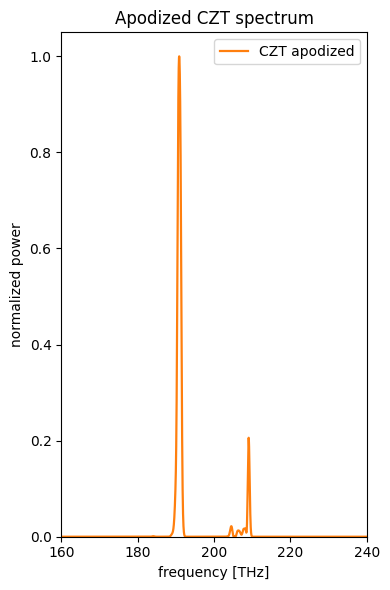

In [23]:
# Plot only the CZT-apodized spectrum and run ResonanceFinder on apodized signal.

import xarray as xr

# 1) CZT-apodized spectrum only
plt.figure(figsize=(4, 6))
plt.plot(f * 1e-12, fd_apod_n, lw=1.6, color="tab:orange", label="CZT apodized")
plt.xlim(f1 * 1e-12, f2 * 1e-12)
plt.ylim(0, 1.05)
plt.xlabel("frequency [THz]")
plt.ylabel("normalized power")
plt.title("Apodized CZT spectrum")
plt.legend()
plt.tight_layout()
plt.show()

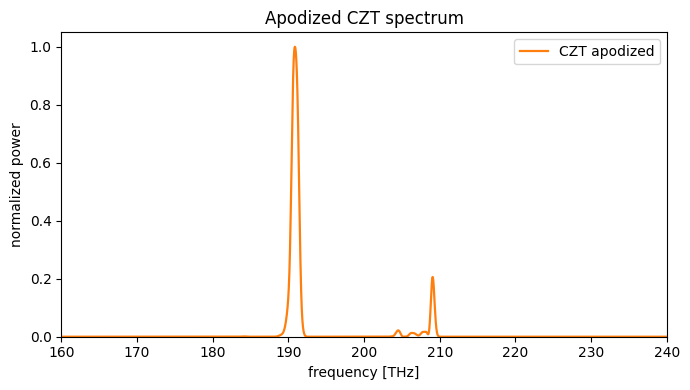

Resonances from apodized monitor signal:


,freq_THz,Q,amplitude,phase,error
freq,,,,,
1.829549e+14,182.954898,7159.406650,2.496153e-05,-0.119020,0.001099
1.842256e+14,184.225595,-466.325972,7.756215e-07,0.574679,0.000465
1.846257e+14,184.625710,415.079550,1.177258e-05,-2.606519,0.001043
1.850202e+14,185.020170,-48.956502,3.149137e-05,1.567531,0.002616
1.859384e+14,185.938406,-1314.158098,6.154562e-06,1.840198,0.000325
1.865350e+14,186.534975,-4060.929633,5.991881e-07,-0.978520,0.000398
1.884725e+14,188.472458,-585.119314,4.944714e-06,-0.159923,0.000378
1.888576e+14,188.857634,-320.513771,2.206755e-05,1.038696,0.000530
1.890905e+14,189.090481,-438.139545,1.308145e-05,2.782750,0.000282


In [ ]:


# 2) ResonanceFinder on apodized time signal
# Build a full-length apodization window to keep array shape compatible with monitor data.
ref_mdat = sim_data[time_monitor_names[0]]
t_full = np.asarray(ref_mdat.Ex.coords["t"].values, dtype=float)

window_full = np.zeros_like(t_full, dtype=float)
mask_full = t_full >= t_cut

if mask_full.sum() < 10:
    raise RuntimeError("Too few samples remain after t_cut for ResonanceFinder.")

t_after = t_full[mask_full] - t_full[mask_full][0]
T_after = t_after.max()
if T_after <= 0:
    raise RuntimeError("Selected post-cut window has zero duration.")

window_after = np.exp(-0.5 * ((t_after - T_after * apod_center) ** 2) / ((apod_width * T_after) ** 2))
window_full[mask_full] = window_after

window_da = xr.DataArray(window_full, coords={"t": ref_mdat.Ex.coords["t"]}, dims=["t"])

# Apply same temporal window to all E components so ResonanceFinder can use field data.
Ex_apod = ref_mdat.Ex * window_da
Ey_apod = ref_mdat.Ey * window_da
Ez_apod = ref_mdat.Ez * window_da

# Build an apodized FieldTimeData object (compatible with ResonanceFinder.run).
try:
    apodized_field = ref_mdat.updated_copy(Ex=Ex_apod, Ey=Ey_apod, Ez=Ez_apod)
except Exception:
    apodized_field = ref_mdat.copy(update={"Ex": Ex_apod, "Ey": Ey_apod, "Ez": Ez_apod})

resonance_finder_apod = ResonanceFinder(freq_window=(f1, f2), init_num_freqs=100)
resonance_data_apod = resonance_finder_apod.run(apodized_field)

resonance_df_apod = resonance_data_apod.to_dataframe()

# Handle both output styles: frequency as a column or as index.
if "freq" in resonance_df_apod.columns:
    freq_vals = resonance_df_apod["freq"].to_numpy()
else:
    freq_vals = resonance_df_apod.index.to_numpy()

resonance_df_apod = resonance_df_apod.copy()
resonance_df_apod["freq_THz"] = freq_vals * 1e-12

# Keep only columns that exist in this tidy3d version.
show_cols = [c for c in ["freq_THz", "Q", "amplitude", "phase", "error"] if c in resonance_df_apod.columns]

print("Resonances from apodized monitor signal:")
display(resonance_df_apod[show_cols].sort_values("freq_THz"))